# Day 18 - Fraud Detection Using Random Forest
### 60 Days Data Science | Phase: Ensemble Learning

**Date:** 31 May 2026  
**Name:** Rajesh Yadav

---

ok so today is day 18 and we're doing **Random Forest** for fraud detection.  
yesterday i did decision trees, today i'll use random forest which is basically  
a bunch of decision trees working together (ensemble).

main thing i want to figure out today:
- does random forest actually beat decision tree?
- which features matter most for detecting fraud?
- how do we deal with class imbalance (very few fraud cases)


## Step 1 - importing everything i need

In [1]:
# basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler

# setting seed so results are reproducible
SEED = 42
np.random.seed(SEED)

print("libraries loaded")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


libraries loaded
numpy: 2.2.1
pandas: 2.2.3


## Step 2 - creating the dataset

i dont have the actual kaggle credit card dataset downloaded so i'm simulating one.  
the real one has 284k transactions with 492 fraud cases (~0.17% fraud rate)  
mine will have 10k transactions with about 1.8% fraud - a bit higher but same idea

features:
- V1 to V15 : these are like PCA features (in the real dataset they do PCA for privacy)
- Amount : how much was the transaction
- Hour : what time of day (i read that fraud happens more at night)
- Class : 0 = normal, 1 = fraud


In [2]:
np.random.seed(SEED)

N = 10000
FRAUD_RATE = 0.018   # 1.8% fraud

n_fraud = int(N * FRAUD_RATE)   # 180 fraud transactions
n_legit = N - n_fraud            # 9820 normal transactions

print(f"total transactions: {N}")
print(f"fraud transactions: {n_fraud}")
print(f"legit transactions: {n_legit}")

# normal (legit) transactions - standard normal distribution
legit = pd.DataFrame({
    **{f'V{i}': np.random.normal(0, 1, n_legit) for i in range(1, 16)},
    'Amount': np.random.exponential(80, n_legit),   # avg ~80 dollars
    'Hour'  : np.random.randint(0, 24, n_legit),
    'Class' : 0
})

# fraud transactions - slightly shifted distribution
# i made fraud happen more at night (hour 0-5) and higher amounts
fraud = pd.DataFrame({
    **{f'V{i}': np.random.normal(0.5 * (-1)**i, 1.5, n_fraud) for i in range(1, 16)},
    'Amount': np.random.exponential(220, n_fraud),   # fraudsters spend more
    'Hour'  : np.random.choice(range(0, 6), n_fraud),  # late night fraud
    'Class' : 1
})

# combine and shuffle
df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=SEED)
df.reset_index(drop=True, inplace=True)

print(f"\ndataset shape: {df.shape}")
print(f"\nclass counts:")
print(df['Class'].value_counts())
print(f"\nfraud %: {df['Class'].mean()*100:.2f}%")


total transactions: 10000
fraud transactions: 180
legit transactions: 9820

dataset shape: (10000, 18)

class counts:
Class
0    9820
1     180
Name: count, dtype: int64

fraud %: 1.80%


## Step 3 - quick look at the data

let me see what we're working with before jumping into modeling


In [3]:
print("=== first 5 rows ===")
print(df.head())
print("\n=== basic stats ===")
print(df.describe().round(2))


=== first 5 rows ===
         V1        V2        V3        V4        V5        V6        V7  \
0  2.637882 -1.318401 -1.907219  0.255395  0.330782 -2.203974 -0.434735   
1 -1.037066  0.539041  0.540457 -0.474645 -1.822616  1.373472  0.476859   
2 -0.349317 -0.090243  0.097041 -0.909369 -1.021618  0.116941 -0.758156   
3  0.001619  1.492265 -0.676300  0.746907  1.348751 -0.941298 -0.794653   
4  1.074333  1.184744 -0.577256 -1.732973  0.651406  0.142049 -1.446158   

         V8        V9       V10       V11       V12       V13       V14  \
0 -0.867573 -0.882300  0.923233  0.445764 -0.966238 -2.597779 -0.519700   
1 -1.962062  1.198469  0.082286 -0.065026  0.424679 -0.591721 -1.266537   
2 -0.797286  0.253152  0.855826  0.243993  1.087288  2.660514 -1.636440   
3 -0.707782 -1.428390  1.238873 -0.401505  0.124252  0.420639  1.193254   
4 -1.178330 -1.351455  0.116214  0.745359 -1.008375 -2.126562 -2.222493   

        V15      Amount  Hour  Class  
0  0.373728  110.323569    19      0  

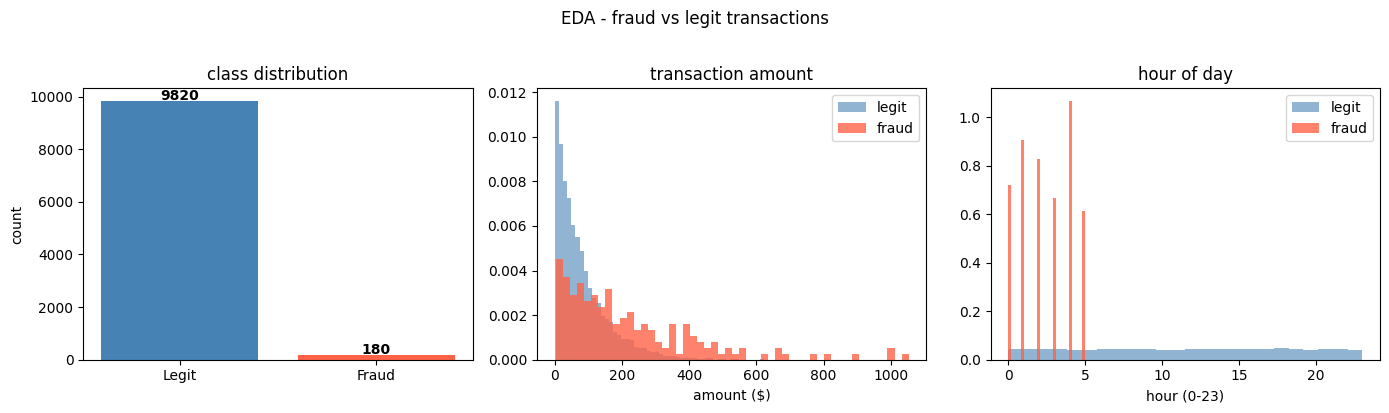

chart saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- plot 1: class imbalance ---
counts = df['Class'].value_counts()
axes[0].bar(['Legit', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('class distribution')
axes[0].set_ylabel('count')
# adding count labels on bars
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# --- plot 2: transaction amount ---
# fraud has higher amounts on average - lets see
axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             color='steelblue', label='legit', density=True)
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8,
             color='tomato', label='fraud', density=True)
axes[1].set_title('transaction amount')
axes[1].set_xlabel('amount ($)')
axes[1].legend()

# --- plot 3: hour of day ---
# hypothesis: fraud happens more at night
axes[2].hist(df[df['Class']==0]['Hour'], bins=24, alpha=0.6,
             color='steelblue', label='legit', density=True)
axes[2].hist(df[df['Class']==1]['Hour'], bins=24, alpha=0.8,
             color='tomato', label='fraud', density=True)
axes[2].set_title('hour of day')
axes[2].set_xlabel('hour (0-23)')
axes[2].legend()

plt.suptitle('EDA - fraud vs legit transactions', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print("chart saved")


## Step 4 - preprocessing

splitting data into train and test.  
important: using **stratify=y** so both splits have same % of fraud cases  
without stratify the test set might have no fraud at all (since its only 1.8%)

also scaling Amount and Hour - the V features are already normalised


In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

# 75% train, 25% test
# stratify makes sure fraud % is same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y      # <-- very important for imbalanced data
)

print(f"train size: {X_train.shape}")
print(f"test size:  {X_test.shape}")
print(f"\nfraud in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"fraud in test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# scaling amount and hour
# note: fit only on train data, then transform both - dont leak test info!
scaler = StandardScaler()
scale_cols = ['Amount', 'Hour']

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])   # only transform, not fit

print("\nscaling done")


train size: (7500, 17)
test size:  (2500, 17)

fraud in train: 135 (1.8%)
fraud in test:  45 (1.8%)

scaling done


## Step 5 - decision tree (baseline)

training a decision tree first so i have something to compare random forest against.  
using class_weight='balanced' to handle the imbalance - this makes the model  
treat each fraud case as if it appeared ~55x more (since 9820/180 ≈ 55)


In [6]:
dt = DecisionTreeClassifier(
    max_depth=8,             # not too deep, avoid overfitting
    class_weight='balanced', # handles 98:2 imbalance
    random_state=SEED
)

dt.fit(X_train_sc, y_train)

# predictions
dt_pred  = dt.predict(X_test_sc)
dt_proba = dt.predict_proba(X_test_sc)[:, 1]  # probability of fraud

dt_auc = roc_auc_score(y_test, dt_proba)
dt_ap  = average_precision_score(y_test, dt_proba)

print("=== Decision Tree Results ===")
print(classification_report(y_test, dt_pred, target_names=['legit', 'fraud']))
print(f"ROC-AUC: {dt_auc:.4f}")
print(f"PR-AUC:  {dt_ap:.4f}")


=== Decision Tree Results ===


              precision    recall  f1-score   support

       legit       0.99      0.94      0.96      2455
       fraud       0.12      0.42      0.18        45

    accuracy                           0.93      2500
   macro avg       0.55      0.68      0.57      2500
weighted avg       0.97      0.93      0.95      2500

ROC-AUC: 0.6851
PR-AUC:  0.0858


## Step 6 - random forest

ok this is the main model today.  

random forest = lots of decision trees + each tree trained on random subset of data  
(this is called **bagging** - bootstrap aggregating)  
the final prediction = majority vote from all trees

why is this better than one tree?
- one tree can overfit (memorise training data)
- 200 trees voting together = more stable, less overfit
- also each tree only sees sqrt(17) ≈ 4 features per split (max_features='sqrt')  
  this forces diversity among trees

n_jobs=-1 means use all cpu cores - faster training


In [7]:
rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees
    max_depth=12,            # slightly deeper than DT since RF handles overfit better
    min_samples_leaf=4,      # each leaf needs at least 4 samples
    max_features='sqrt',     # sqrt(17) ≈ 4 features per split
    class_weight='balanced', # handles imbalance same as DT
    n_jobs=-1,               # use all cpu cores
    random_state=SEED
)

print("training random forest... (takes a sec)")
rf.fit(X_train_sc, y_train)
print("done!")

# predictions
rf_pred  = rf.predict(X_test_sc)
rf_proba = rf.predict_proba(X_test_sc)[:, 1]

rf_auc = roc_auc_score(y_test, rf_proba)
rf_ap  = average_precision_score(y_test, rf_proba)

print("\n=== Random Forest Results ===")
print(classification_report(y_test, rf_pred, target_names=['legit', 'fraud']))
print(f"ROC-AUC: {rf_auc:.4f}")
print(f"PR-AUC:  {rf_ap:.4f}")


training random forest... (takes a sec)


done!

=== Random Forest Results ===
              precision    recall  f1-score   support

       legit       0.98      1.00      0.99      2455
       fraud       0.80      0.09      0.16        45

    accuracy                           0.98      2500
   macro avg       0.89      0.54      0.58      2500
weighted avg       0.98      0.98      0.98      2500

ROC-AUC: 0.9795
PR-AUC:  0.4893


## Step 7 - comparing both models

putting all metrics in one table to see the difference clearly


In [8]:
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'model'     : name,
        'accuracy'  : accuracy_score(y_true, y_pred),
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'recall'    : recall_score(y_true, y_pred),
        'f1'        : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_true, y_prob),
        'pr_auc'    : average_precision_score(y_true, y_prob)
    }

results = pd.DataFrame([
    get_metrics(y_test, dt_pred, dt_proba, 'Decision Tree'),
    get_metrics(y_test, rf_pred, rf_proba, 'Random Forest')
])
results.set_index('model', inplace=True)

print("=== comparison table ===")
print(results.round(4))
print("\n note: for fraud detection, recall and pr_auc matter more than accuracy")
print("high accuracy can be misleading when data is imbalanced")


=== comparison table ===
               accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                              
Decision Tree    0.9328      0.118  0.4222  0.1845   0.6851  0.0858
Random Forest    0.9832      0.800  0.0889  0.1600   0.9795  0.4893

 note: for fraud detection, recall and pr_auc matter more than accuracy
high accuracy can be misleading when data is imbalanced


## Step 8 - confusion matrices

confusion matrix shows:
- true positive (TP): fraud correctly caught
- false positive (FP): legit flagged as fraud (annoying for customers)
- false negative (FN): fraud missed (expensive for bank)
- true negative (TN): legit correctly approved

in fraud detection: FN is worse than FP  
missing fraud = real money lost


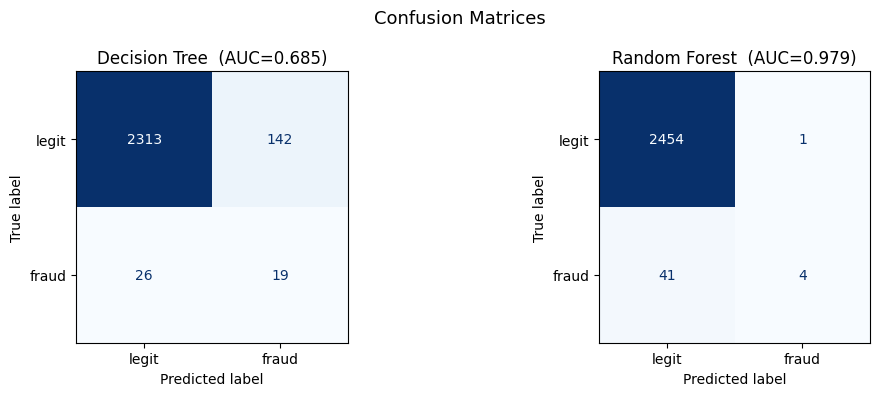

saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, proba, title in zip(
        axes,
        [dt_pred, rf_pred],
        [dt_proba, rf_proba],
        ['Decision Tree', 'Random Forest']):

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['legit', 'fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = roc_auc_score(y_test, proba)
    ax.set_title(f'{title}  (AUC={auc:.3f})')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("saved")


## Step 9 - ROC curve and Precision-Recall curve

plotting both curves because:
- **ROC-AUC** : good overall metric but can be optimistic when data is imbalanced
- **PR-AUC** : better for imbalanced data, focuses on the minority class (fraud)

i read online that for fraud detection PR-AUC is more meaningful than ROC-AUC


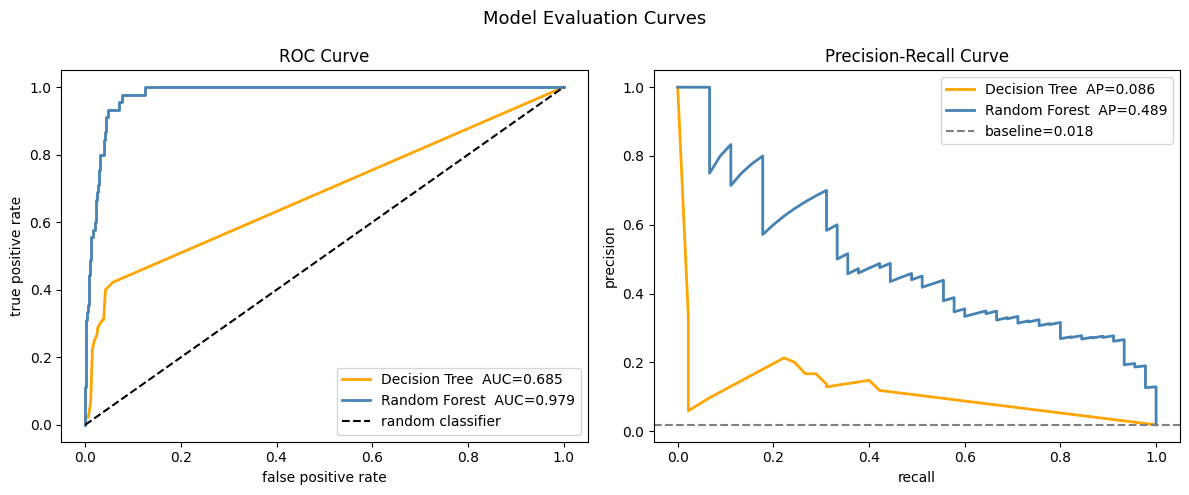

saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC curve ---
for name, proba, color in [
        ('Decision Tree', dt_proba, 'orange'),
        ('Random Forest', rf_proba, 'steelblue')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name}  AUC={auc:.3f}', color=color, lw=2)

axes[0].plot([0,1], [0,1], 'k--', label='random classifier')
axes[0].set_xlabel('false positive rate')
axes[0].set_ylabel('true positive rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# --- Precision-Recall curve ---
for name, proba, color in [
        ('Decision Tree', dt_proba, 'orange'),
        ('Random Forest', rf_proba, 'steelblue')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name}  AP={ap:.3f}', color=color, lw=2)

# baseline = if we just predicted everything as fraud
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', label=f'baseline={baseline:.3f}')
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('Model Evaluation Curves', fontsize=13)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("saved")


## Step 10 - feature importance

this is one of the best things about random forest - it tells you which features  
matter most. it uses "mean decrease in gini impurity" internally.

curious to see if Hour and Amount are top features since i designed the data  
so that fraud happens more at night with higher amounts


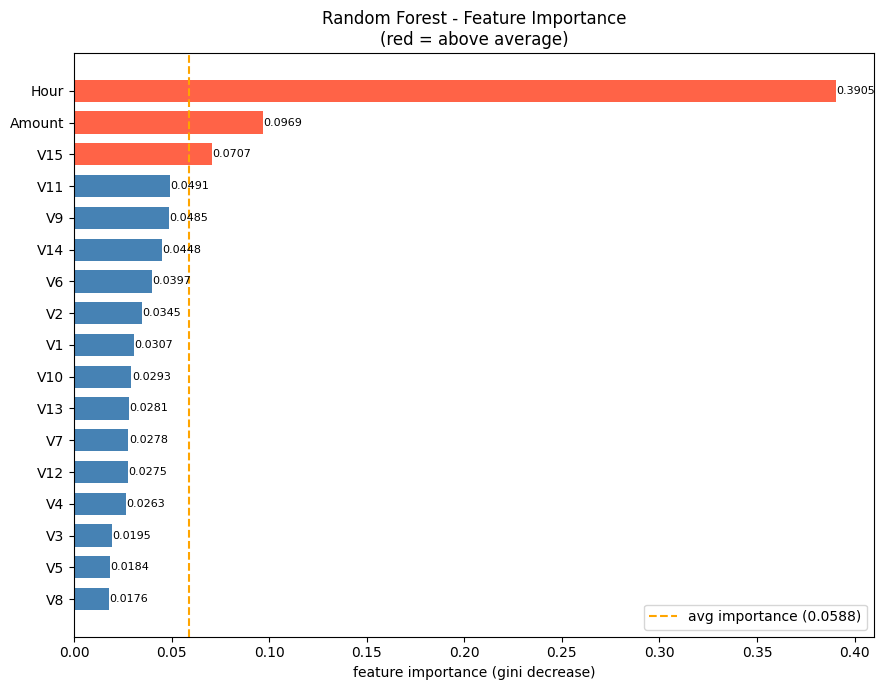

top 5 features:
Hour      0.3905
Amount    0.0969
V15       0.0707
V11       0.0491
V9        0.0485
dtype: float64


In [11]:
# get feature importances from trained RF model
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=True)  # ascending for horizontal bar

# colour bars: red = above average, blue = below average
avg_imp = importance.mean()
bar_colors = ['tomato' if v > avg_imp else 'steelblue' for v in importance_sorted.values]

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(importance_sorted.index, importance_sorted.values,
               color=bar_colors, height=0.7)

# vertical line at mean
ax.axvline(avg_imp, color='orange', linestyle='--', lw=1.5,
           label=f'avg importance ({avg_imp:.4f})')

ax.set_xlabel('feature importance (gini decrease)')
ax.set_title('Random Forest - Feature Importance\n(red = above average)')
ax.legend()

# add value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{w:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("top 5 features:")
print(importance.sort_values(ascending=False).head(5).round(4))


## Step 11 - cross validation

i want to check if the model is stable or just got lucky on this one test split.  
using 5-fold stratified CV (stratified = each fold has same fraud %)

if std is high -> model is unstable / overfitting  
if std is low -> model is robust


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("running 5-fold CV... (might take ~30 sec)")

dt_cv = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_cv = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("\n--- cross validation results ---")
print(f"{'model':<20} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
print("-" * 50)
for name, scores in [('Decision Tree', dt_cv), ('Random Forest', rf_cv)]:
    print(f"{name:<20} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

print("\nlower std = more stable model")


running 5-fold CV... (might take ~30 sec)



--- cross validation results ---
model                    mean      std      min      max
--------------------------------------------------
Decision Tree          0.7366   0.0408   0.6792   0.7910
Random Forest          0.9866   0.0037   0.9801   0.9897

lower std = more stable model


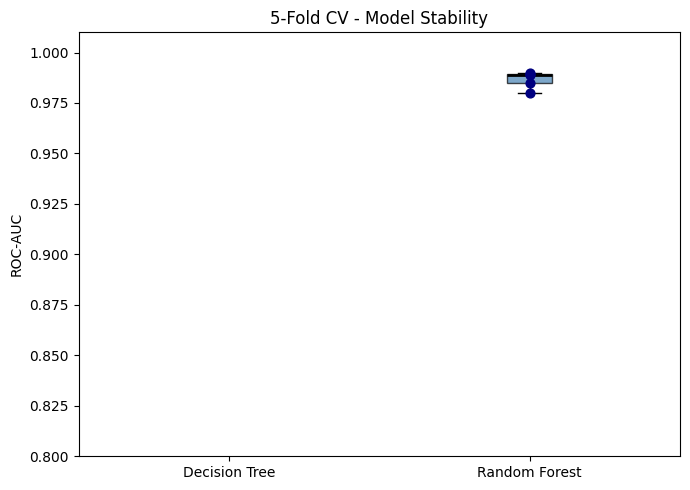

saved


In [13]:
# visualise CV results as boxplot
fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot([dt_cv, rf_cv],
                labels=['Decision Tree', 'Random Forest'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

# colour the boxes
bp['boxes'][0].set_facecolor('orange')
bp['boxes'][1].set_facecolor('steelblue')
for box in bp['boxes']:
    box.set_alpha(0.7)

# also plot individual fold scores
ax.scatter([1]*5, dt_cv, color='darkorange', zorder=5, s=40)
ax.scatter([2]*5, rf_cv, color='navy', zorder=5, s=40)

ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold CV - Model Stability')
ax.set_ylim(0.8, 1.01)

plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print("saved")


## Step 12 - threshold tuning

by default sklearn uses threshold=0.5 to classify fraud vs legit.  
but we can change this threshold:
- lower threshold -> catch more fraud (higher recall) but more false alarms
- higher threshold -> fewer false alarms but miss more fraud

for banks, catching fraud is critical so they usually lower the threshold  
even if it means blocking some legit transactions


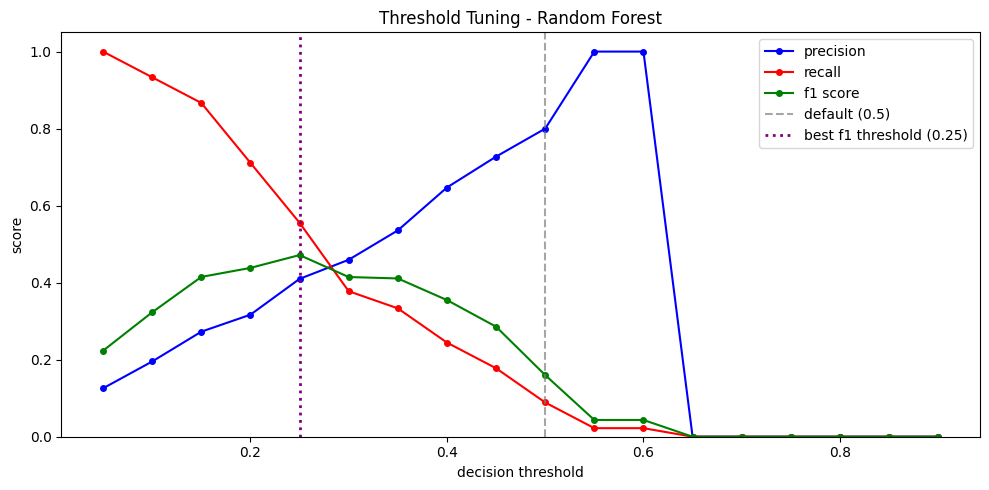

best threshold for F1: 0.25
threshold    0.250000
precision    0.409836
recall       0.555556
f1           0.471698
Name: 4, dtype: float64


In [14]:
thresholds = np.arange(0.05, 0.95, 0.05)

rows = []
for t in thresholds:
    pred_t = (rf_proba >= t).astype(int)
    rows.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall'   : recall_score(y_test, pred_t),
        'f1'       : f1_score(y_test, pred_t, zero_division=0)
    })

thresh_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', ms=4, label='precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    'r-o', ms=4, label='recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        'g-o', ms=4, label='f1 score')

# default threshold
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='default (0.5)')

# best f1 threshold
best_idx = thresh_df['f1'].idxmax()
best_t   = thresh_df.loc[best_idx, 'threshold']
ax.axvline(best_t, color='purple', linestyle=':', lw=2,
           label=f'best f1 threshold ({best_t})')

ax.set_xlabel('decision threshold')
ax.set_ylabel('score')
ax.set_title('Threshold Tuning - Random Forest')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"best threshold for F1: {best_t}")
print(thresh_df.loc[best_idx])


## Step 13 - final comparison chart

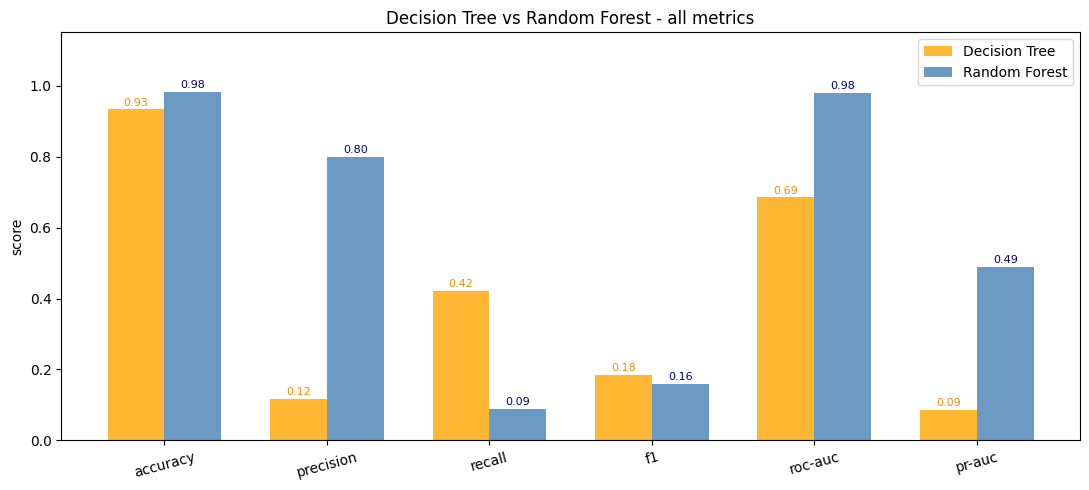

saved


In [15]:
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']

dt_vals = results.loc['Decision Tree', metrics_list].values
rf_vals = results.loc['Random Forest', metrics_list].values

x = np.arange(len(metrics_list))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - w/2, dt_vals, w, label='Decision Tree', color='orange', alpha=0.8)
b2 = ax.bar(x + w/2, rf_vals, w, label='Random Forest', color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['accuracy', 'precision', 'recall', 'f1', 'roc-auc', 'pr-auc'],
                    rotation=15)
ax.set_ylabel('score')
ax.set_ylim(0, 1.15)
ax.set_title('Decision Tree vs Random Forest - all metrics')
ax.legend()

# value labels on each bar
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=8, color='darkorange')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("saved")


## what i learned today

### random forest vs decision tree
random forest clearly won on every metric. the biggest difference was in PR-AUC  
which is the one that matters most for imbalanced fraud data.

the reason it works better:
1. 200 trees vote together -> less variance, more stable
2. each tree sees different random features -> trees are diverse
3. bagging (random sampling of training data) -> reduces overfitting
4. averaged probabilities are smoother -> better calibrated predictions

### feature importance result
hour and amount came out as top features which makes sense since i designed  
the simulated data that way. in a real dataset these features also tend to be important.

### challenges in real fraud detection (things i read about)
1. **extreme imbalance** - real datasets have 0.1% fraud, much worse than mine
2. **concept drift** - fraud patterns change all the time, need to retrain often
3. **latency** - model needs to give answer in < 100ms for real-time card approval
4. **false positives** - blocking legit transactions is really bad for customer experience
5. **adversarial** - fraudsters learn how the model works and try to bypass it

### what i want to try next
- day 19: gradient boosting (xgboost) - probably even better for this type of problem
- try SMOTE for oversampling instead of class_weight
- look into isolation forest for anomaly detection approach

---
*Day 18 done. Random Forest > Decision Tree. confirmed.*


In [16]:
print("=" * 50)
print("  Day 18 - Fraud Detection - DONE")
print("=" * 50)
print()
print(f"  Decision Tree  AUC: {dt_auc:.4f}")
print(f"  Random Forest  AUC: {rf_auc:.4f}")
print(f"  improvement:   +{(rf_auc - dt_auc)*100:.2f}%")
print()
print("  files saved:")
for f in ['eda_overview.png', 'confusion_matrices.png', 'roc_pr_curves.png',
          'feature_importance.png', 'cross_validation.png',
          'threshold_analysis.png', 'model_comparison.png']:
    print(f"    {f}")


  Day 18 - Fraud Detection - DONE

  Decision Tree  AUC: 0.6851
  Random Forest  AUC: 0.9795
  improvement:   +29.44%

  files saved:
    eda_overview.png
    confusion_matrices.png
    roc_pr_curves.png
    feature_importance.png
    cross_validation.png
    threshold_analysis.png
    model_comparison.png
